In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import isautilities as isau
import xarray as xr
import sklearn as sk

import pathlib
froot = pathlib.Path().cwd().parent.parent / 'Results/Figures/ISAUnits'
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_intervals.batch'
do_save = False

In [2]:
def _populationGLM(session,regs=None,when='sleep.*#0',n_lags=6,delay=[0],shuffle=1,verbose=False):
    # predict PFC population activity with region spike matrices just before (with history)

    MAX_UNITS = 100
    BALANCE = np.inf
    R = fma.regions.regions(session,phases=when,states='sws',events='InfraSlowRhythm/infraslowaval')
    regs = R.ids if regs is None else np.asarray(regs)[np.isin(regs,R.ids)]

    # X: spike counts with history
    bin_x = 0.02
    fr_x = R.unitFiringRate(regs=regs,window=bin_x,when='sws')
    counts_x = fr_x[:,1:] * bin_x
    time_x = fr_x[:,0]
    n_times, n_units = counts_x.shape
    X = np.zeros((n_times-n_lags+1, n_units*n_lags))
    for t in range(n_lags-1,n_times):
        history = counts_x[t-n_lags+1:t+1][::-1] # reverse lag order
        X[t-n_lags+1] = history.flatten() # X[i]: [counts_x[i+n_lags-1], ..., counts_x[i]], so X[0] corresponds to time[n_lags-1]
    time_x = time_x[n_lags-1:]

    # y: PFC activity
    bin_y = 0.01
    fr_y = R.unitFiringRate(regs='pfc',window=bin_y)
    counts_y = (fr_y[:,1:] > 0).astype(float)
    counts_y = counts_y[:, np.any(np.diff(counts_y,axis=0),axis=0)] # remove units with no spikes (zero-variance columns)
    time_y = fr_y[:,0]

    target_idx = np.searchsorted(time_y,time_x)
    valid = (target_idx < len(fr_y)-max(delay)) & np.insert(target_idx[:-1] != target_idx[1:],0,True)
    target_idx = target_idx[valid]
    X = X[valid]
    time_x = time_x[valid]

    # ISA
    isa = R.eventIntervals('slownr')
    nrem = R.eventIntervals('sws')
    is_isa = isau.isISA(time_x,isa,nrem)

    n_cv = 5
    #cv = sk.model_selection.TimeSeriesSplit(n_splits=n_cv,gap=50)
    cv = sk.model_selection.StratifiedKFold(n_splits=n_cv,shuffle=True,random_state=42)
    def cv_score(X,y):
        # model = sk.pipeline.make_pipeline(
        #     sk.preprocessing.StandardScaler(),
        #     sk.linear_model.PoissonRegressor(alpha=1.0,max_iter=5000))
        model = sk.linear_model.LogisticRegression(C=0.0001,max_iter=5000)
        #model = sk.linear_model.LogisticRegression(solver='saga',l1_ratio=0.5,max_iter=5000)
        #model = sk.linear_model.SGDClassifier(loss="log_loss",penalty="elasticnet",l1_ratio=0.5,max_iter=100,tol=1e-3,random_state=42)
        return sk.model_selection.cross_val_score(model,X,y,cv=cv,scoring='average_precision',n_jobs=-1)


    rng = np.random.default_rng()
    scores = np.full((2,n_cv,len(delay),shuffle+1),np.nan)
    delays = np.full(len(delay),np.nan)
    for a in range(2): # 0: ISA, 1: nISA
        valid = is_isa == a
        verbose and print(f'ISA: {not a}')
        target_idx_isa = target_idx[valid]
        X_isa = X[valid]
        time_x_isa = time_x[valid]

        for j, d in enumerate(delay):
            # TEMP TIME
            this_time_y = time_y[target_idx_isa+d]
            not np.all(np.isclose(np.diff(this_time_y-time_x_isa),0,atol=1e-6)) and print('! ',end='')
            delays[j] = this_time_y[0] - time_x_isa[0]
            verbose and print(f'delay: {d} ({delays[j]*1000:.2f} ms)')

            # train per neuron
            verbose and print(f'units (out of {counts_y.shape[1]}): ',end='')
            for i in range(counts_y.shape[1]):
                verbose and i % 10 == 0 and print(f'{i} ',end='')
                if i > MAX_UNITS:
                    break

                # 1. observed
                y = counts_y[target_idx_isa+d,i]
                if y.sum() < 5:
                    continue
                # BALANCE
                valid = y != 0
                #print(f'({valid.sum()},',end='')
                valid[rng.choice(len(y), size=min(valid.sum()*BALANCE,len(y)), replace=False)] = True
                np.any(~valid) and print('! ',end='')
                X_i = X_isa[valid]
                y_i = y[valid]
                #print(f'{len(y_i)},{len(y)}) ',end='')
                scores[a,:,j,0] = cv_score(X_i,y_i)

                # 2. surrogate
                for k in range(shuffle):
                    rng.shuffle(y_i)
                    scores[a,:,j,k+1] = cv_score(X_i,y_i)
            print()

    scores = xr.DataArray(scores,dims=['isa','cv','t','shuffle'],coords={'isa': [True,False], 't': delays, 'shuffle': [False]+[True]*shuffle, 'rat': int(R.rat)})
    match shuffle:
        case 0: gain = scores.sel(shuffle=False) * np.nan
        case 1: gain = scores.sel(shuffle=False) / scores.sel(shuffle=True)
        case _: gain = scores.sel(shuffle=False) / scores.sel(shuffle=True).mean(dim='shuffle')

    return scores, gain

In [ ]:
 # test on one session
session = fma.data.readBatchFile(batch_file)[0][19]
print(session)
regs = ['hpc','nr','pfc'] # ,['hpc','nr']
keys = ['hpc','nr','pfc'] # ,'hpc+nr'
delay = np.arange(1,20)
scores = {}
gain = {}
for i, r in enumerate(regs):
    scores[keys[i]], gain[keys[i]] = _populationGLM(session,regs=r,when='sleep.*#0',n_lags=1,delay=delay,shuffle=1,verbose=True)
    print()

/mnt/hubel-data-140/karadoc/Rat004_20240306/Rat004_20240306.xml
ISA: True
delay: 1 (15.00 ms)
units (out of 79): 0 

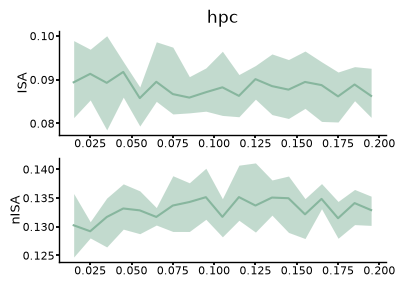

In [4]:
# see scores DIVIDE ISA nISA
fig, ax = fma.plotting.makeFigure(size=(10,7),n=(2,len(scores)))
ax = np.array(ax,ndmin=2)
for i, k in enumerate(keys):
    for j, a in enumerate([True,False]):
        #fma.plotting.semPlot(gain[k].t,gain[k],color=isau.paperColors(k),ax=ax[i])
        fma.plotting.semPlot(scores[k].t,scores[k].sel(isa=a,shuffle=False),color=isau.paperColors(k),ax=ax[i,j])
        #fma.plotting.semPlot(scores[k].t,scores[k].sel(shuffle=True),color=isau.paperColors('shuffle'),ax=ax[i,j])
    ax[i,0].set(title=keys[i])
ax[0,0].set(ylabel='ISA'), ax[0,1].set(ylabel='nISA');

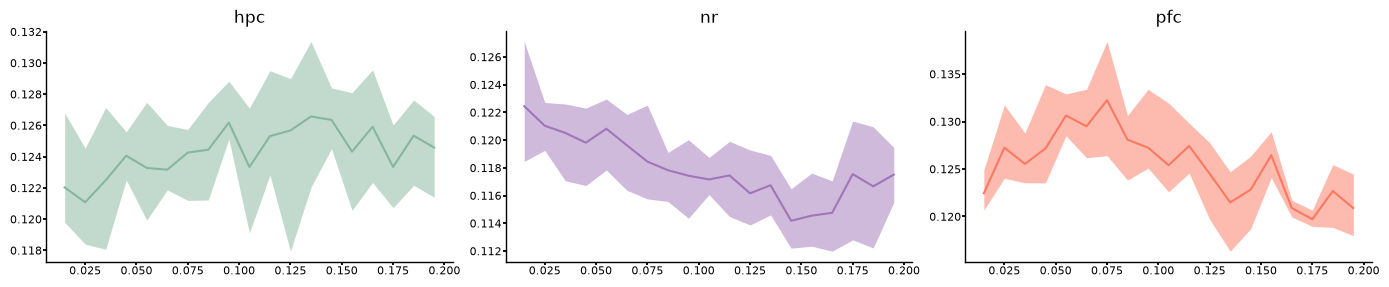

In [4]:
# see scores DIVIDE ISA nISA
fig, ax = fma.plotting.makeFigure(size=(35,7),n=(1,len(scores)))
for i, k in enumerate(keys):
    #fma.plotting.semPlot(gain[k].t,gain[k],color=isau.paperColors(k),ax=ax[i])
    fma.plotting.semPlot(scores[k].t,scores[k].sel(shuffle=False),color=isau.paperColors(k),ax=ax[i])
    #fma.plotting.semPlot(scores[k].t,scores[k].sel(shuffle=True),color=isau.paperColors('shuffle'),ax=ax[i])
    ax[i].set(title=keys[i])

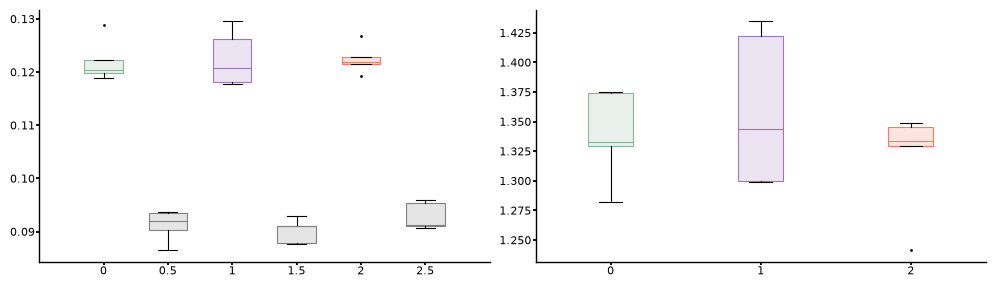

In [5]:
# see scores
fig, ax = fma.plotting.makeFigure(n=(1,2),size=(25,7))
data = {r: [scores[r].sel(shuffle=False).isel(t=0)] for r in scores}
data_sh = {r: [scores[r].sel(shuffle=True).isel(t=0)] for r in scores}
fma.plotting.boxPlot(data.values(),x=np.arange(len(scores)),color=isau.paperColors(list(scores.keys())),ax=ax[0])
fma.plotting.boxPlot(data_sh.values(),x=.5+np.arange(len(scores)),color='grey',ax=ax[0])

data = {r: [gain[r].isel(t=0)] for r in gain}
fma.plotting.boxPlot(data.values(),x=np.arange(len(scores)),color=isau.paperColors(list(scores.keys())),ax=ax[1])

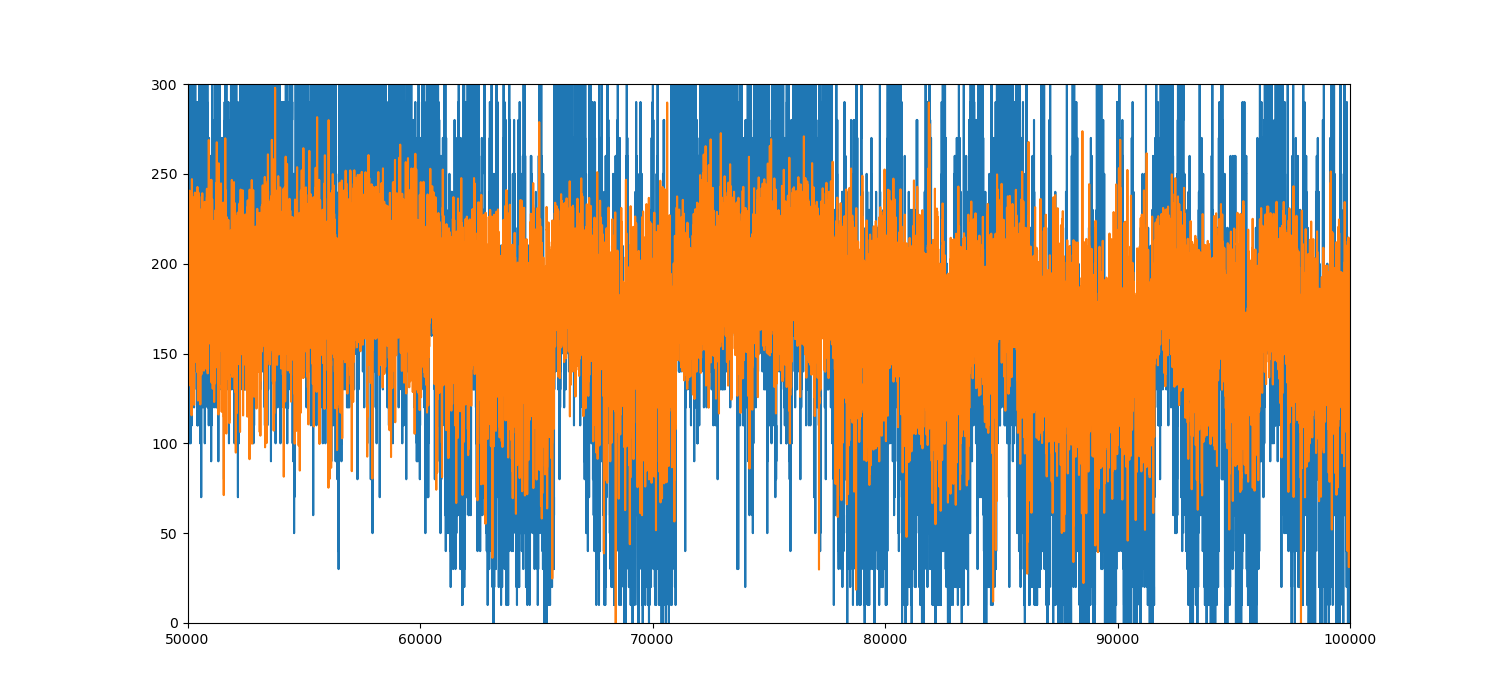

In [5]:
fig, axs = plt.subplots(1,1,figsize=[15,7])
start = 50000
stop = 100000
key = 'hpc'
axs.plot(range(start,stop),true[start:stop])
axs.plot(range(start,stop),prediction[key][start:stop])
# plot unit activity
#axs.plot(range(start,stop),X[key][start:stop,10])
#axs.plot(range(start,stop),X[key][start:stop,23])
#axs.plot(range(start,stop),X[key][start:stop,37])
# plot summed population activity
#axs.plot(range(start,stop),np.sum(X[key],1)[start:stop])
axs.set_xlim([start,stop]); axs.set_ylim([0,300]);
#plt.show()

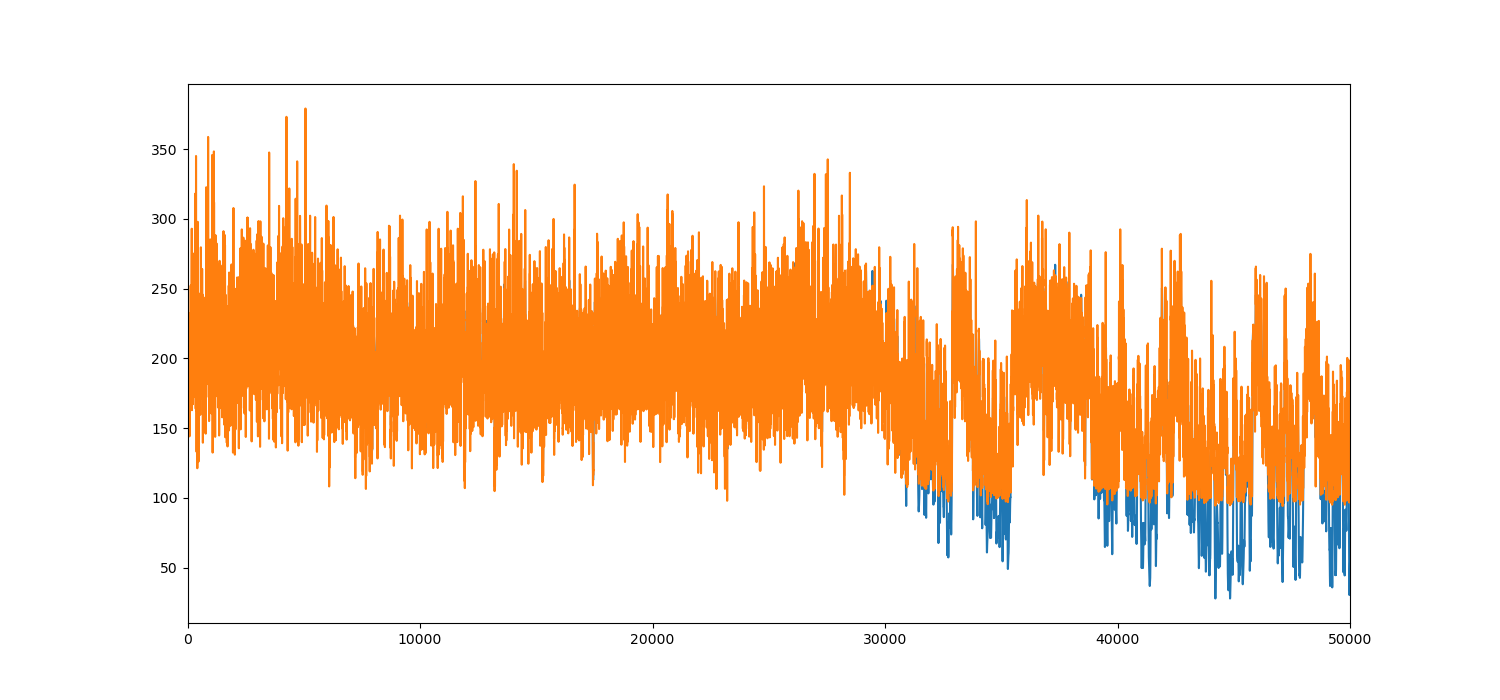

In [10]:
fig, axs = plt.subplots(1,1,figsize=[15,7])
start = 0
stop = 50000
axs.plot(true[start:stop])
#axs.plot(prediction['hpc'][start:stop])
#axs.plot(prediction['pfc'][start:stop])
axs.plot(prediction['nr'][start:stop])
axs.set_xlim([start,stop]);
plt.show()